In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install kaggle

!mkdir -p KGAT_f78cf5b36dec0da3b05142ff25ad1055/.kaggle/
!cp kaggle.json KGAT_f78cf5b36dec0da3b05142ff25ad1055/.kaggle/
!chmod 600 KGAT_f78cf5b36dec0da3b05142ff25ad1055/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access 'KGAT_f78cf5b36dec0da3b05142ff25ad1055/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
replace chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace chest_xray/__MACOSX/chest_xray/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace chest_xray/__MACOSX/chest_xray/._test? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace chest_xray/__MACOSX/chest_xray/._train? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace chest_xray/__MACOSX/chest_xray/test/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace chest_xray/__MACOSX/chest_xray/test/._NORMAL? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace chest_xray/__MACOSX/chest_xray/test/._PNEUMONIA? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0001-0001.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: yy
replace chest_xray/__MACOSX/chest_xray/t

In [ ]:
from torchvision import datasets, transforms

train_dir = "/content/chest_xray/train"

basic_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(train_dir, transform=basic_tf)

print(train_ds.classes)
print(train_ds.class_to_idx)
print(len(train_ds))

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}
5216


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
from torchvision import datasets, transforms

basic_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(train_dir, transform=basic_tf)

print(train_ds.classes)
print(train_ds.class_to_idx)
print(len(train_ds))

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}
5216


torch.Size([3, 224, 224]) label: 0 NORMAL


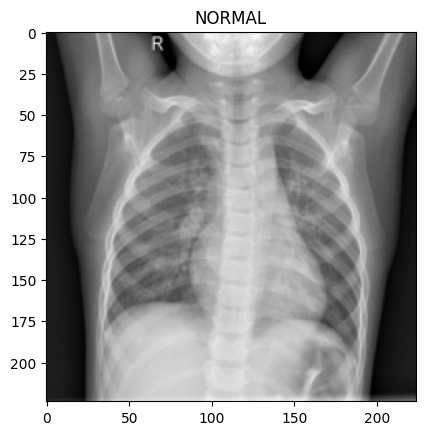

In [ ]:
import matplotlib.pyplot as plt

img, label = train_ds[0]
print(img.shape, 'label:', label, train_ds.classes[label])

plt.imshow(img.permute(1, 2, 0))
plt.title(train_ds.classes[label])
plt.show()

torch.Size([3, 224, 224]) label: 1 PNEUMONIA


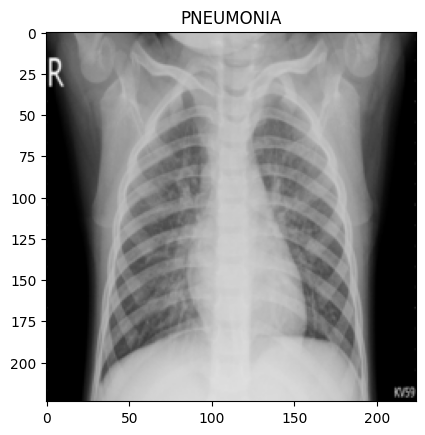

In [ ]:
import matplotlib.pyplot as plt

img, label = train_ds[4000]
print(img.shape, 'label:', label, train_ds.classes[label])

plt.imshow(img.permute(1, 2, 0))
plt.title(train_ds.classes[label])
plt.show()

In [ ]:
import numpy as np

targets = np.array(train_ds.targets)
n_normal = (targets == 0).sum()
n_pneumonia = (targets == 1).sum()
print("NORMAL:", n_normal, "PNEUMONIA:", n_pneumonia)
print("ratio(pneu/norm):", n_pneumonia / n_normal)

NORMAL: 1341 PNEUMONIA: 3875
ratio(pneu/norm): 2.889634601043997


In [ ]:
from matplotlib.colors import Normalize
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

In [ ]:
val_dir = '/content/chest_xray/val'
test_dir = '/content/chest_xray/test'
train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
val_ds = datasets.ImageFolder(val_dir, transform=eval_tf)
test_ds = datasets.ImageFolder(test_dir, transform=eval_tf)

In [ ]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
img_tr, label_tr = next(iter(train_loader))
img_val, label_val = next(iter(val_loader))
img_test, label_test = next(iter(test_loader))
print(img_tr.shape)
print(img_val.shape)
print(img_test.shape)

torch.Size([32, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([32, 3, 224, 224])


In [ ]:
img, loader = next(iter(train_loader))
print(img.shape)

torch.Size([32, 3, 224, 224])


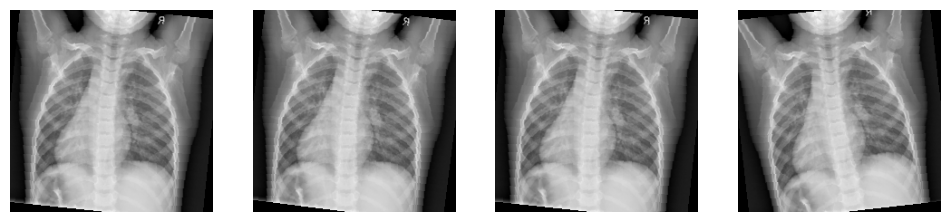

In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# ★ 시각화 전용 파이프라인 (Normalize는 뺀다 — 이유는 아래 생각할 거리)
demo_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])
demo_ds = datasets.ImageFolder(train_dir, transform=demo_tf)

# 같은 인덱스(0번)를 여러 번 꺼내 나란히 띄워보기
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax in axes:
    img, _ = demo_ds[0]                 # 매번 다시 꺼내면 증강이 새로 적용됨
    ax.imshow(img.permute(1,2,0))        # [C,H,W] → [H,W,C] (1주차 그 함정)
    ax.axis("off")
plt.show()

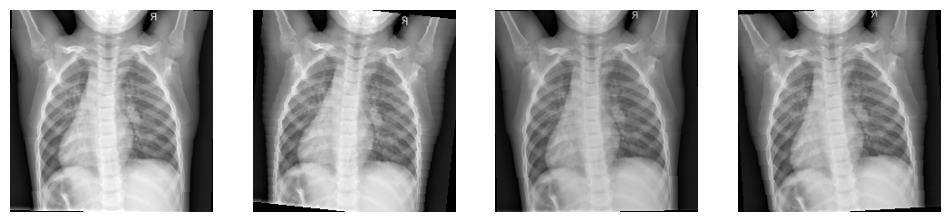

torch.Size([64, 3, 224, 224])


In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 과제 1 — train용 transform (증강 포함)
# 목표: 증강 + Resize + ToTensor + Normalize를 올바른 순서로 묶는다.
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 과제 2 — val/test용 transform (고정 변환만)
# 목표: 증강 없이, 평가용 고정 파이프라인을 만든다.
eval_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 과제 3 — 증강이 매번 다르게 적용되는 걸 눈으로 확인
# 목표: 같은 이미지를 여러 번 꺼내 띄워, 무작위 증강 때문에 매번 달라지는 걸 확인한다.
demo_dir = '/content/chest_xray/train'
demo_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
])
demo_ds = datasets.ImageFolder(demo_dir, transform=demo_tf)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax in axes:
    img, _ = demo_ds[0]
    ax.imshow(img.permute(1,2,0))
    ax.axis('off')
plt.show()

# 과제 4 — train/val/test DataLoader 완성 + 배치 모양 확인
# 목표: 세 로더를 갖추고, 배치 하나의 모양을 확인한다.
val_dir = '/content/chest_xray/val'
test_dir = '/content/chest_xray/test'
val_ds = datasets.ImageFolder(val_dir, transform=eval_tf)
test_ds = datasets.ImageFolder(test_dir, transform=eval_tf)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
img, label = next(iter(train_loader))
print(img.shape)


In [ ]:
from torch.nn.modules.pooling import MaxPool2d
import torch, torch.nn as nn

dummy = torch.randn(1, 3, 224, 224)
model = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(64 * 28 * 28, 2)
)
print(model(dummy).shape)
nn.Flatten()

torch.Size([1, 2])


Flatten(start_dim=1, end_dim=-1)

In [ ]:
loss_fn = nn.CrossEntropyLoss()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 3
for epoch in range(n_epochs):
  model.train()
  running = 0.0
  for images,labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = loss_fn(outputs, labels)
    loss.backward()
    optimizer.step()
    running += loss.item()
  train_loss = running / len(train_loader)

  model.eval()
  val_running = 0.0
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      val_running += loss_fn(model(images), labels).item()
  val_loss = val_running / len(val_loader)

  print(f"epoch{epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")


epoch1: train_loss=0.3471, val_loss=0.2991
epoch2: train_loss=0.2083, val_loss=0.2708
epoch3: train_loss=0.1793, val_loss=0.2431


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    preds = outputs.argmax(dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

print("recall   :", recall_score(all_labels, all_preds))
print("precision:", precision_score(all_labels, all_preds))
print("F1       :", f1_score(all_labels, all_preds))
print(confusion_matrix(all_labels, all_preds))


recall   : 1.0
precision: 0.7386363636363636
F1       : 0.8496732026143791
[[ 96 138]
 [  0 390]]


In [ ]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for params in model.parameters():
  params.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:
for params in model.parameters():
  params.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
for params in model.layer4.parameters():
  params.requires_grad = True

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for params in model.parameters():
  params.requires_grad = False
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

n_epochs = 3
for epoch in range(n_epochs):
  model.train()
  running = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    out = model(images)
    loss = loss_fn(out, labels)
    loss.backward()
    optimizer.step()
    running += loss.item()
  train_loss = running / len(train_loader)
  model.eval()
  val_running = 0.0
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      val_running += loss_fn(model(images), labels).item()
  val_loss = val_running / len(val_loader)
  print(f"epoch{epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

epoch1: train_loss=0.3973, val_loss=0.3307
epoch2: train_loss=0.2204, val_loss=0.2551
epoch3: train_loss=0.1927, val_loss=0.2750


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    preds = outputs.argmax(dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

print("recall   :", recall_score(all_labels, all_preds))
print("precision:", precision_score(all_labels, all_preds))
print("F1       :", f1_score(all_labels, all_preds))
print(confusion_matrix(all_labels, all_preds))


recall   : 0.9846153846153847
precision: 0.8329718004338394
F1       : 0.9024676850763808
[[157  77]
 [  6 384]]


In [ ]:
for param in model.parameters():
  param.requires_grad = True

optimizer = torch.optim.Adam(model.layer4.parameters(), lr=1e-4)

n_epochs = 3
for epoch in range(n_epochs):
  model.train()
  running = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    out = model(images)
    loss = loss_fn(out, labels)
    loss.backward()
    optimizer.step()
    running += loss.item()
  train_loss = running / len(train_loader)
  model.eval()
  val_running = 0.0
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      val_running += loss_fn(model(images), labels).item()
  val_loss = val_running / len(val_loader)
  print(f"epoch{epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

epoch1: train_loss=0.1004, val_loss=0.7979
epoch2: train_loss=0.0612, val_loss=1.1564
epoch3: train_loss=0.0488, val_loss=0.4611


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    preds = outputs.argmax(dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

print("recall   :", recall_score(all_labels, all_preds))
print("precision:", precision_score(all_labels, all_preds))
print("F1       :", f1_score(all_labels, all_preds))
print(confusion_matrix(all_labels, all_preds))


recall   : 0.9615384615384616
precision: 0.8865248226950354
F1       : 0.922509225092251
[[186  48]
 [ 15 375]]
